In [15]:
!pip install cdsapi

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
!ls /content/drive/MyDrive/FourCastProject/data

era5_test.nc  means.npy  stds.npy  X.npy  Y.npy


In [21]:
from google.colab import userdata

url = userdata.get("CDSAPI_URL")
key = userdata.get("CDSAPI_KEY")

with open("/root/.cdsapirc", "w") as f:
    f.write(f"url: {url}\n")
    f.write(f"key: {key}\n")

print("CDS configured")

CDS configured


In [22]:
import cdsapi

client = cdsapi.Client()
print("Connected")

Connected


In [23]:
client.retrieve(
    "reanalysis-era5-single-levels",
    {
        "product_type": "reanalysis",
        "variable": [
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
            "2m_temperature",
            "mean_sea_level_pressure",
        ],
        "year": "2023",
        "month": "01",
        "day": [
            "01","02","03","04","05","06","07","08","09","10",
            "11","12","13","14","15","16","17","18","19","20",
            "21","22","23","24","25","26","27","28","29","30","31"
        ],
        "time": [
            "00:00",
            "06:00",
            "12:00",
            "18:00"
        ],
        "area": [
            -60,
            50,
            -90,
            100
        ],
        "format": "netcdf",
    },
    "/content/drive/MyDrive/FourCastProject/data/era5_jan2023.nc",
)

2026-05-31 08:04:38,995 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

88d26e389b59621b6c5425cb4135fb4c.nc:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

'/content/drive/MyDrive/FourCastProject/data/era5_jan2023.nc'

In [24]:
!ls /content/drive/MyDrive/FourCastProject/data

era5_jan2023.nc  era5_test.nc  means.npy  stds.npy  X.npy  Y.npy


In [25]:
import xarray as xr

ds = xr.open_dataset(
    "/content/drive/MyDrive/FourCastProject/data/era5_jan2023.nc"
)

print(ds)

<xarray.Dataset> Size: 48MB
Dimensions:     (valid_time: 124, latitude: 121, longitude: 201)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 2023-01-01 ... 2023-01-31T18...
  * latitude    (latitude) float64 968B -60.0 -60.25 -60.5 ... -89.75 -90.0
  * longitude   (longitude) float64 2kB 50.0 50.25 50.5 ... 99.5 99.75 100.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 12MB ...
    v10         (valid_time, latitude, longitude) float32 12MB ...
    t2m         (valid_time, latitude, longitude) float32 12MB ...
    msl         (valid_time, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026

In [27]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 124, 'latitude': 121, 'longitude': 201})


In [28]:
import numpy as np

data = np.stack(
    [
        ds["u10"].values,
        ds["v10"].values,
        ds["t2m"].values,
        ds["msl"].values,
    ],
    axis=1
)

print(data.shape)

(124, 4, 121, 201)


In [29]:
means = data.mean(axis=(0,2,3))
stds  = data.std(axis=(0,2,3))

data_norm = data.copy()

for c in range(4):
    data_norm[:,c] = (
        data_norm[:,c] - means[c]
    ) / stds[c]

In [30]:
input_steps = 4

X = []
Y = []

for i in range(len(data_norm) - input_steps):
    X.append(data_norm[i:i+input_steps])
    Y.append(data_norm[i+input_steps])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(X.shape)
print(Y.shape)

(120, 4, 4, 121, 201)
(120, 4, 121, 201)


In [31]:
np.save(
    "/content/drive/MyDrive/FourCastProject/data/X_jan2023.npy",
    X
)

np.save(
    "/content/drive/MyDrive/FourCastProject/data/Y_jan2023.npy",
    Y
)

np.save(
    "/content/drive/MyDrive/FourCastProject/data/means_jan2023.npy",
    means
)

np.save(
    "/content/drive/MyDrive/FourCastProject/data/stds_jan2023.npy",
    stds
)

In [32]:
!ls /content/drive/MyDrive/FourCastProject/data

era5_jan2023.nc    means.npy	     X_jan2023.npy  Y.npy
era5_test.nc	   stds_jan2023.npy  X.npy
means_jan2023.npy  stds.npy	     Y_jan2023.npy


In [33]:
import numpy as np

X = np.load(
    "/content/drive/MyDrive/FourCastProject/data/X_jan2023.npy"
)

Y = np.load(
    "/content/drive/MyDrive/FourCastProject/data/Y_jan2023.npy"
)

print(X.shape)
print(Y.shape)

(120, 4, 4, 121, 201)
(120, 4, 121, 201)


In [34]:
import torch
from torch.utils.data import Dataset

class ERA5Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [35]:
from torch.utils.data import random_split

dataset = ERA5Dataset(X, Y)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

print(len(train_dataset))
print(len(test_dataset))

96
24


In [36]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [37]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 4, kernel_size=3, padding=1)
        )

    def forward(self, x):
        B,T,C,H,W = x.shape

        x = x.reshape(B, T*C, H, W)

        return self.net(x)

In [38]:
model = BaselineCNN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Model ready")

Model ready


In [39]:
x_batch, y_batch = next(iter(train_loader))

output = model(x_batch)

print("Input :", x_batch.shape)
print("Output:", output.shape)
print("Target:", y_batch.shape)

Input : torch.Size([4, 4, 4, 121, 201])
Output: torch.Size([4, 4, 121, 201])
Target: torch.Size([4, 4, 121, 201])


In [40]:
print(output.shape)
print(y_batch.shape)

torch.Size([4, 4, 121, 201])
torch.Size([4, 4, 121, 201])


In [41]:
loss = criterion(output, y_batch)
print(loss.item())

1.0740435123443604


In [42]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()

        output = model(x_batch)

        loss = criterion(output, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/10 | Loss: 0.397778
Epoch 2/10 | Loss: 0.172543
Epoch 3/10 | Loss: 0.125242
Epoch 4/10 | Loss: 0.107334
Epoch 5/10 | Loss: 0.098125
Epoch 6/10 | Loss: 0.094522
Epoch 7/10 | Loss: 0.093488
Epoch 8/10 | Loss: 0.091350
Epoch 9/10 | Loss: 0.084250
Epoch 10/10 | Loss: 0.081977


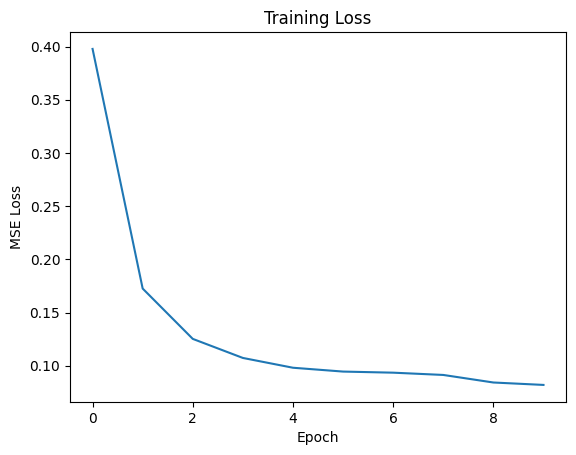

In [43]:
import matplotlib.pyplot as plt

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training Loss")

plt.show()

In [44]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/FourCastProject/checkpoints/baseline_cnn_jan2023.pth"
)

In [45]:
sample_x, sample_y = test_dataset[0]

sample_x = sample_x.unsqueeze(0)

prediction = model(sample_x)

print(prediction.shape)

torch.Size([1, 4, 121, 201])


In [46]:
model.eval()

test_loss = 0

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        output = model(x_batch)

        loss = criterion(output, y_batch)

        test_loss += loss.item()

test_loss /= len(test_loader)

print("Test Loss:", test_loss)

Test Loss: 0.09369978308677673


In [47]:
sample_x, sample_y = test_dataset[0]

sample_x = sample_x.unsqueeze(0)

model.eval()

with torch.no_grad():
    prediction = model(sample_x)

print(prediction.shape)

torch.Size([1, 4, 121, 201])


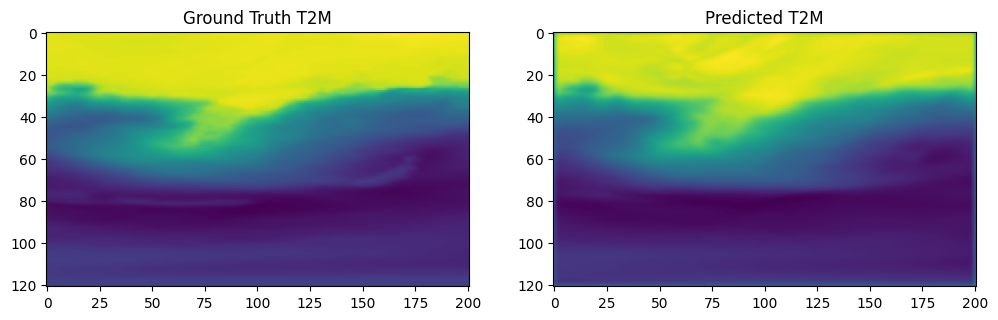

In [48]:
import matplotlib.pyplot as plt

truth = sample_y[2].numpy()

pred = prediction.squeeze(0)[2].numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(truth)
plt.title("Ground Truth T2M")

plt.subplot(1,2,2)
plt.imshow(pred)
plt.title("Predicted T2M")

plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!find /content/drive/MyDrive -name "*.npy"

/content/drive/MyDrive/FourCastProject/data/X.npy
/content/drive/MyDrive/FourCastProject/data/Y.npy
/content/drive/MyDrive/FourCastProject/data/stds.npy
/content/drive/MyDrive/FourCastProject/data/means.npy
/content/drive/MyDrive/FourCastProject/data/X_jan2023.npy
/content/drive/MyDrive/FourCastProject/data/Y_jan2023.npy
/content/drive/MyDrive/FourCastProject/data/means_jan2023.npy
/content/drive/MyDrive/FourCastProject/data/stds_jan2023.npy


In [8]:
!find /content/drive/MyDrive -name "*.nc"

/content/drive/MyDrive/FourCastProject/data/era5_test.nc
/content/drive/MyDrive/FourCastProject/data/era5_jan2023.nc


In [9]:
!find /content/drive/MyDrive -name "*.pth"

/content/drive/MyDrive/FourCastProject/checkpoints/baseline_cnn_jan2023.pth


In [12]:
import numpy as np

X = np.load(
    "/content/drive/MyDrive/FourCastProject/data/X_jan2023.npy"
)

Y = np.load(
    "/content/drive/MyDrive/FourCastProject/data/Y_jan2023.npy"
)

print(X.shape)
print(Y.shape)

(120, 4, 4, 121, 201)
(120, 4, 121, 201)


In [13]:
import torch
from torch.utils.data import Dataset

class ERA5Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [14]:
from torch.utils.data import random_split, DataLoader

dataset = ERA5Dataset(X, Y)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [17]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 4, kernel_size=3, padding=1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.reshape(B, T * C, H, W)

        return self.net(x)

In [18]:
model = BaselineCNN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Model ready")

Model ready


In [19]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/FourCastProject/checkpoints/baseline_cnn_jan2023.pth"
)

In [20]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()

        output = model(x_batch)

        loss = criterion(output, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.6f}"
    )

Epoch 1/10 | Loss: 0.455163
Epoch 2/10 | Loss: 0.182960
Epoch 3/10 | Loss: 0.129343
Epoch 4/10 | Loss: 0.114246
Epoch 5/10 | Loss: 0.104679
Epoch 6/10 | Loss: 0.099686
Epoch 7/10 | Loss: 0.093122
Epoch 8/10 | Loss: 0.091713
Epoch 9/10 | Loss: 0.090419
Epoch 10/10 | Loss: 0.085267


In [21]:
import os

os.makedirs(
    "/content/drive/MyDrive/FourCastProject/checkpoints",
    exist_ok=True
)

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/FourCastProject/checkpoints/baseline_cnn_jan2023.pth"
)

print("Checkpoint saved")

Checkpoint saved


In [22]:
!find /content/drive/MyDrive/FourCastProject -name "*.pth"

/content/drive/MyDrive/FourCastProject/checkpoints/baseline_cnn_jan2023.pth


In [23]:
model.eval()

test_loss = 0

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        output = model(x_batch)

        loss = criterion(output, y_batch)

        test_loss += loss.item()

test_loss /= len(test_loader)

print("Test Loss:", test_loss)

Test Loss: 0.08346546317140262


In [24]:
sample_x, sample_y = test_dataset[0]

sample_x = sample_x.unsqueeze(0)

model.eval()

with torch.no_grad():
    prediction = model(sample_x)

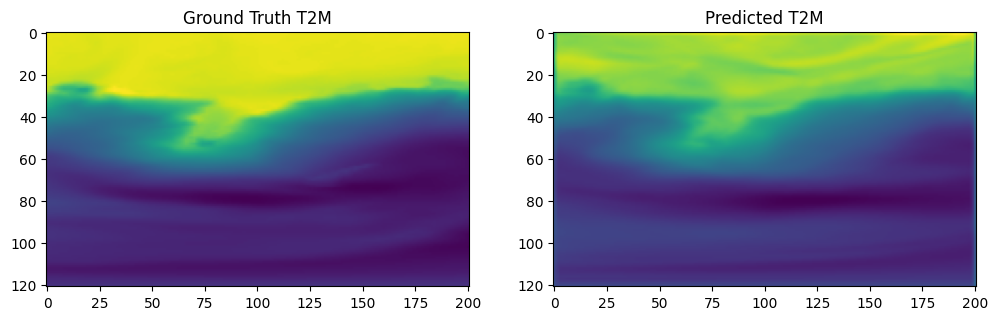

In [25]:
import matplotlib.pyplot as plt

truth = sample_y[2].numpy()

pred = prediction.squeeze(0)[2].numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(truth)
plt.title("Ground Truth T2M")

plt.subplot(1,2,2)
plt.imshow(pred)
plt.title("Predicted T2M")

plt.show()

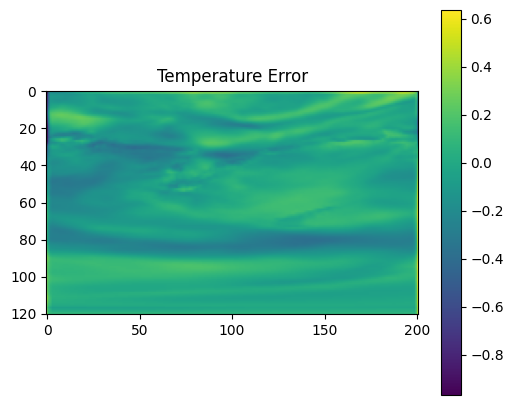

In [26]:
error = pred - truth

plt.figure(figsize=(6,5))
plt.imshow(error)
plt.colorbar()
plt.title("Temperature Error")
plt.show()

In [27]:
import numpy as np

rmse = np.sqrt(np.mean((pred - truth)**2))

print("RMSE:", rmse)

RMSE: 0.13598217


In [28]:
import os

os.makedirs(
    "/content/drive/MyDrive/FourCastProject/checkpoints",
    exist_ok=True
)

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/FourCastProject/checkpoints/baseline_cnn_jan2023.pth"
)

print("Checkpoint saved")

Checkpoint saved


In [30]:
results = {
    "train_loss": float(train_losses[-1]),
    "test_loss": float(test_loss),
    "rmse": float(rmse)
}

print(results)

{'train_loss': 0.08526726082588236, 'test_loss': 0.08346546317140262, 'rmse': 0.13598217070102692}


In [31]:
import json

with open(
    "/content/drive/MyDrive/FourCastProject/results_baseline.json",
    "w"
) as f:
    json.dump(results, f, indent=4)

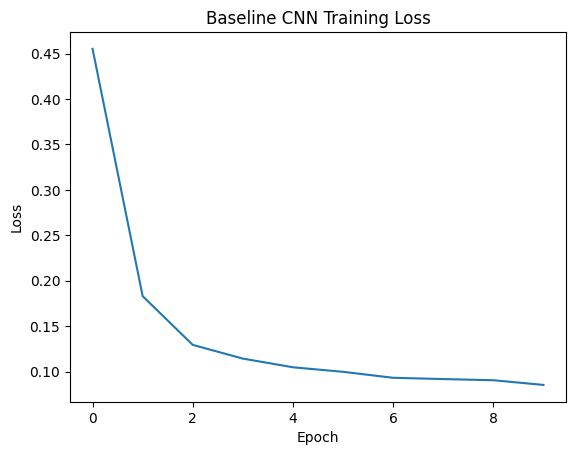

In [32]:
import matplotlib.pyplot as plt

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Training Loss")

plt.savefig(
    "/content/drive/MyDrive/FourCastProject/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
plt.savefig(
    "/content/drive/MyDrive/FourCastProject/t2m_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [35]:
plt.savefig(
    "/content/drive/MyDrive/FourCastProject/error_map.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>